In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
df = pd.read_csv('placement.csv')

In [8]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


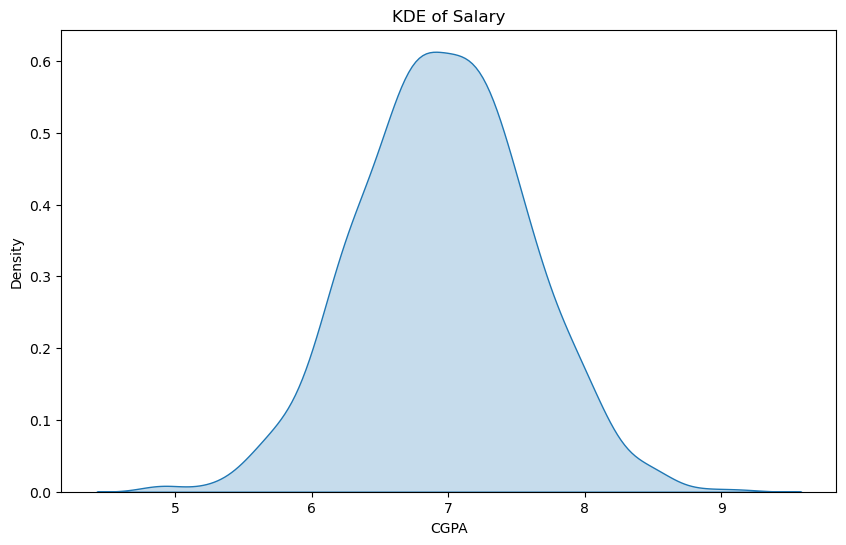

In [10]:
plt.figure(figsize=(10, 6))
plt.title('KDE of Salary')
sns.kdeplot(df['cgpa'], fill=True)
plt.xlabel('CGPA')
plt.ylabel('Density')
plt.show()

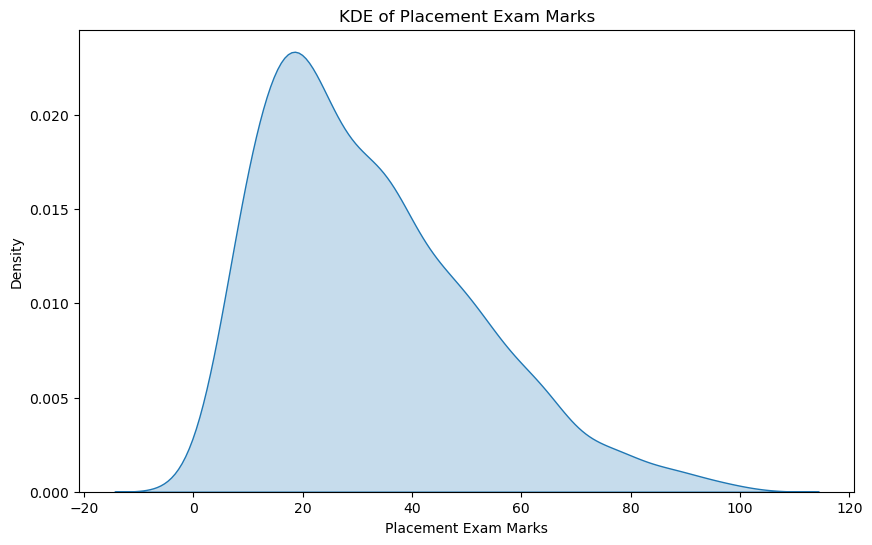

In [11]:
plt.figure(figsize=(10, 6))
plt.title('KDE of Placement Exam Marks')
sns.kdeplot(df['placement_exam_marks'], fill=True)
plt.xlabel('Placement Exam Marks')
plt.ylabel('Density')
plt.show()

In [12]:
#Z score is applied to cgpa only

In [13]:
print("mean of cgpa:", df['cgpa'].mean())
print("mean of cgpa:", df['cgpa'].std())
print("mean of cgpa:", df['cgpa'].min())
print("mean of cgpa:", df['cgpa'].max())

mean of cgpa: 6.96124
mean of cgpa: 0.6158978751323894
mean of cgpa: 4.89
mean of cgpa: 9.12


In [14]:
print("Highest allowed cgpa:", df['cgpa'].mean() + 3 * df['cgpa'].std())
print("Lowest allowed cgpa:", df['cgpa'].mean() - 3 * df['cgpa'].std())

Highest allowed cgpa: 8.808933625397168
Lowest allowed cgpa: 5.113546374602832


In [16]:
df[(df['cgpa']>8.80) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [17]:
new_df = df[(df['cgpa']<8.80) & (df['cgpa']>5.11)]

In [18]:
new_df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [19]:
#approach 2
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [20]:
df[df['cgpa_zscore']>3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [21]:
df[df['cgpa_zscore']<-3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [22]:
df[(df['cgpa_zscore']>3) | (df['cgpa_zscore']<-3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [25]:
new_df = df[(df['cgpa_zscore']<3) & (df['cgpa_zscore']>-3)]

In [28]:
new_df.sample(2)

,cgpa,placement_exam_marks,placed,cgpa_zscore
540,6.37,63.0,0,-0.959964
118,6.90,54.0,0,-0.099432


capping


In [29]:
upper_limit = df['cgpa'].mean() + 3 * df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3 * df['cgpa'].std()
print("Highest allowed cgpa:", upper_limit)
print("Lowest allowed cgpa:", lower_limit)

Highest allowed cgpa: 8.808933625397168
Lowest allowed cgpa: 5.113546374602832


In [31]:
#capping the outliers
df['cgpa'] = np.where(df['cgpa']>upper_limit,upper_limit,np.where(df['cgpa']<lower_limit,lower_limit,df['cgpa']))

In [32]:
df.shape

(1000, 4)